In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [16]:
class ResumeState(TypedDict):
    resume : str
    score: int
    feedback: str
    attempts: int

In [17]:
def review_resume(state: ResumeState):
    score = min(60 + state['attempts'] * 10 , 100)

    return {
        "score": score,
        "feedback": "Add more projects to you resumes"
    }

In [24]:
def improve_resume(state: ResumeState):
    improved_resume = (
    state["resume"] + 
    f"\nImprovement {state['attempts'] + 1} : {state['feedback']}"
    )

    return {
        "resume": improved_resume,
        "attempts": state['attempts'] + 1
    }

In [25]:
def route_after_review(state: ResumeState):
    if state['score'] >= 80:
        return END

    if state["attempts"] >= 3:
        return END

    return "improve_resume"

In [26]:
builder = StateGraph(ResumeState)

In [27]:
builder.add_node("review_resume", review_resume)
builder.add_node("improve_resume", improve_resume)

builder.add_edge(START, "review_resume")

builder.add_conditional_edges(
    "review_resume", 
    route_after_review
)

builder.add_edge(
    "improve_resume",
    "review_resume"
)

graph = builder.compile()

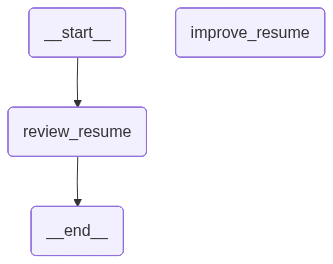

In [28]:
graph

In [29]:
result = graph.invoke(
    {
        "resume": "Python Developer",
        "score": 0,
        "feedback": "",
        "attempts": 0,
    }
)

print(result)

{'resume': 'Python Developer\nImprovement 1 : Add more projects to you resumes\nImprovement 2 : Add more projects to you resumes', 'score': 80, 'feedback': 'Add more projects to you resumes', 'attempts': 2}
